# Influencer Fraud Detection — Improved Pipeline

## Project Goal
Detect suspicious / fraudulent influencer profiles by assigning a **fraud risk score (0–100)**
to every handle in the dataset.

## Approach
Because most data is **unlabeled**, we rely on **unsupervised anomaly detection**:
- **Isolation Forest** — tree-based isolation of outliers  
- **Local Outlier Factor (LOF)** — density-based detection  

A small hand-labeled set (200 profiles: 100 genuine, 100 fraud) is used exclusively for
**threshold calibration** and held-out **validation**.

## Improvements in This Version
| Area | What changed |
|------|-------------|
| EDA | Distribution plots, correlation heatmap, genuine vs. fraud profiling |
| Feature Engineering | 3 new interaction ratios with documented rationale |
| Validation | Stratified k-fold cross-validation + precision / recall / F1 curves |
| Documentation | Inline comments and markdown explanations throughout |
| Explainability | SHAP values for Isolation Forest + LOF score comparison |


## 1 · Import Libraries

| Library | Role |
|---------|------|
| `pandas` | Load and manipulate tabular data |
| `numpy` | Fast numerical operations |
| `matplotlib / seaborn` | Visualisation |
| `StandardScaler` | Zero-mean, unit-variance normalisation before model training |
| `MinMaxScaler` | Re-scale final fraud scores to [0, 100] |
| `IsolationForest` | Tree-based unsupervised anomaly detector |
| `LocalOutlierFactor` | Density-based unsupervised anomaly detector |
| `StratifiedKFold` | Stratified cross-validation on the labeled subset |
| `shap` | Model-agnostic explainability (SHAP values for Isolation Forest) |
| `PCA` | 2-D projection for visual cluster inspection |


In [29]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    precision_recall_curve, roc_auc_score
)
import shap

# ── global plot style ──────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FRAUD_COLOR   = "#e05c5c"   # red  – fraudulent profiles
GENUINE_COLOR = "#4da8da"   # blue – genuine profiles


## 2 · Load Data

The dataset contains **5 000 Instagram/TikTok profile rows** with pre-computed
engagement metrics.  Only 200 rows carry a human-assigned label (`genuine` / `fraud`);
the remaining 4 800 are `unlabeled`.


In [30]:
df = pd.read_csv("Profiles.csv")

print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()


Shape  : (5000, 12)
Columns: ['post_id', 'likes', 'comments', 'shares', 'followers', 'engagement_rate', 'growth rate', 'engagement', 'Clause 1', 'Clause 2', 'Combined', 'Label']


,post_id,likes,comments,shares,followers,engagement_rate,growth rate,engagement,Clause 1,Clause 2,Combined,Label
0,IG0000001,31627,7559,4530,615036,7.11,0.146170,43716,0.0,0.0,0.0,genuine
1,IG0000002,63206,3490,1680,1237071,5.53,0.065073,68376,0.0,0.0,0.0,genuine
2,IG0000003,94373,3727,1761,1127470,8.86,0.067230,99861,0.0,0.0,0.0,genuine
3,IG0000004,172053,7222,2875,764030,23.84,0.052616,182150,1.0,0.0,1.0,fraud
4,IG0000005,99646,2703,4444,7004,1524.74,2.213021,106793,1.0,0.0,1.0,fraud


In [31]:
# ── basic schema ──────────────────────────────────────────────────────────
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          5000 non-null   object 
 1   likes            5000 non-null   int64  
 2   comments         5000 non-null   int64  
 3   shares           5000 non-null   int64  
 4   followers        5000 non-null   int64  
 5   engagement_rate  5000 non-null   float64
 6   growth rate      5000 non-null   float64
 7   engagement       5000 non-null   int64  
 8   Clause 1         200 non-null    float64
 9   Clause 2         200 non-null    float64
 10  Combined         200 non-null    float64
 11  Label            5000 non-null   object 
dtypes: float64(5), int64(5), object(2)
memory usage: 468.9+ KB


In [32]:
# ── summary statistics ────────────────────────────────────────────────────
df.describe().T


,count,mean,std,min,25%,50%,75%,max
likes,5000.0,99642.812800,58512.345884,53.00,49174.500000,98892.500000,1.512238e+05,1.999570e+05
comments,5000.0,5040.966400,2912.724146,1.00,2502.500000,5065.500000,7.581250e+03,1.000000e+04
shares,5000.0,2500.768800,1455.287478,1.00,1242.000000,2473.000000,3.775000e+03,5.000000e+03
followers,5000.0,999676.566400,585312.179861,165.00,485530.750000,999296.500000,1.504537e+06,1.999780e+06
engagement_rate,5000.0,46.329286,343.196255,0.14,5.740000,10.570000,2.208250e+01,1.515228e+04
growth rate,5000.0,0.226895,1.795635,0.00,0.024702,0.049469,1.020287e-01,9.636364e+01
engagement,5000.0,107184.548000,58478.099850,1352.00,56642.000000,106684.000000,1.591668e+05,2.145350e+05
Clause 1,200.0,0.505000,0.501230,0.00,0.000000,1.000000,1.000000e+00,1.000000e+00
Clause 2,200.0,0.005000,0.070711,0.00,0.000000,0.000000,0.000000e+00,1.000000e+00
Combined,200.0,0.510000,0.511083,0.00,0.000000,1.000000,1.000000e+00,2.000000e+00


In [33]:
# ── label distribution ────────────────────────────────────────────────────
print("Label counts:")
print(df["Label"].value_counts(dropna=False))


Label counts:
Label
unlabeled    4800
genuine       100
fraud         100
Name: count, dtype: int64


In [34]:
# ── missing-value audit ───────────────────────────────────────────────────
missing = df.isnull().sum()
print("Null counts per column:")
print(missing[missing > 0] if missing.any() else "No missing values found.")


Null counts per column:
Clause 1    4800
Clause 2    4800
Combined    4800
dtype: int64


## 3 · Exploratory Data Analysis (EDA)

Before modelling, we answer three questions:
1. What do the metric distributions look like?
2. Are there strong correlations that might inflate feature overlap?
3. How clearly do genuine and fraudulent profiles differ on core metrics?

> **Why this matters for explainability** — understanding the data geometry
> helps interpret why the anomaly detectors flag certain profiles.


In [35]:
# ── drop unused columns BEFORE EDA so they don't pollute plots ────────────
df = df.drop(columns=["Clause 1", "Clause 2", "Combined"])

# Separate labeled slice for comparative plots
labeled_df = df[df["Label"].isin(["genuine", "fraud"])].copy()
print(f"Labeled rows: {len(labeled_df)}  (genuine={sum(labeled_df['Label']=='genuine')}, fraud={sum(labeled_df['Label']=='fraud')})")


Labeled rows: 200  (genuine=100, fraud=100)


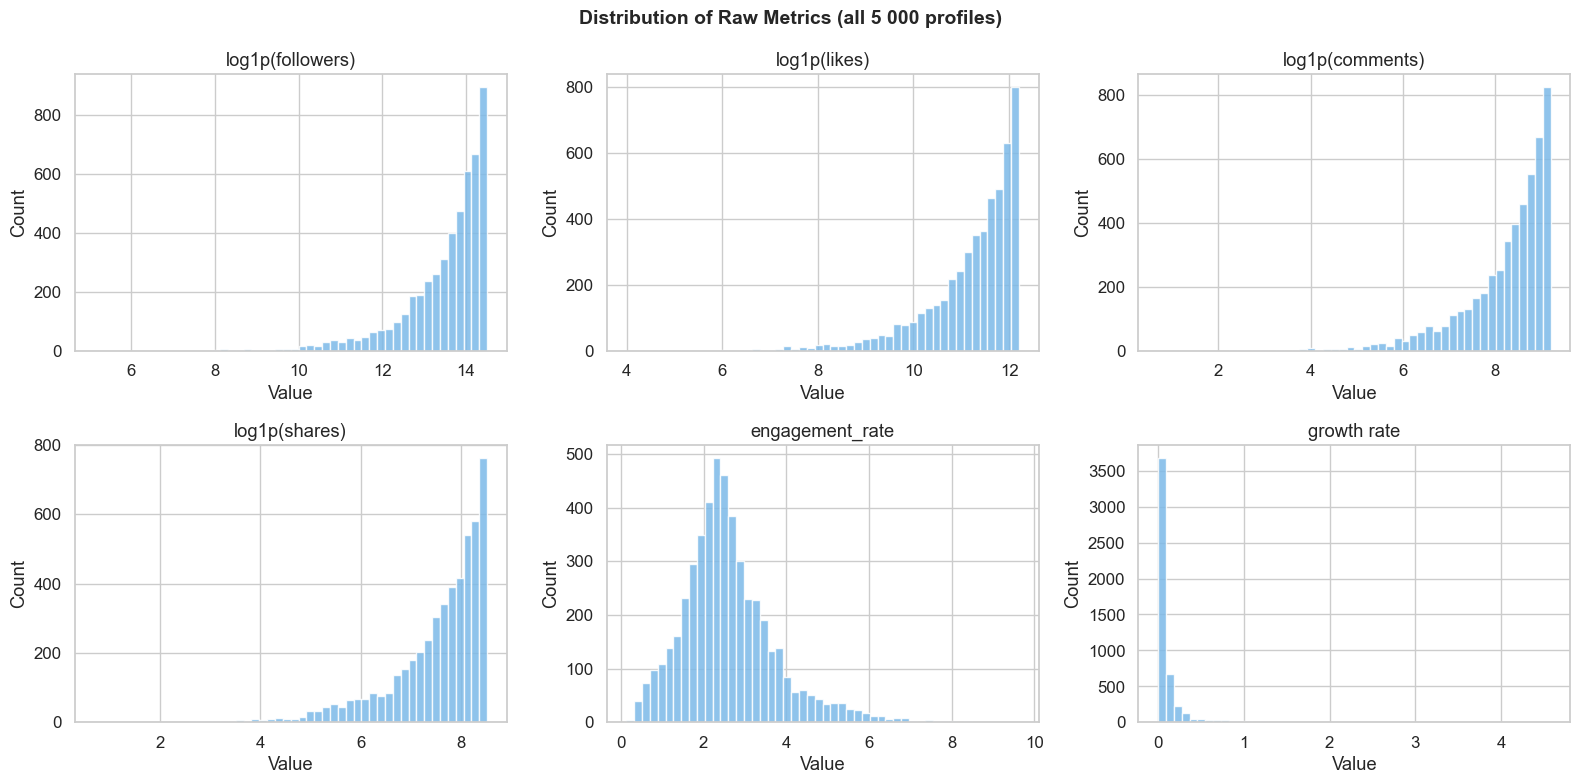

In [36]:
# ── 3.1  Univariate distribution: numeric metrics ─────────────────────────
raw_metrics = ["followers", "likes", "comments", "shares", "engagement_rate", "growth rate"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Distribution of Raw Metrics (all 5 000 profiles)", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flatten(), raw_metrics):
    # log-transform skewed count data to make shape visible
    values = np.log1p(df[col].dropna())
    ax.hist(values, bins=50, color="#7cb9e8", edgecolor="white", alpha=0.85)
    ax.set_title(f"log1p({col})" if col in ["followers","likes","comments","shares"] else col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


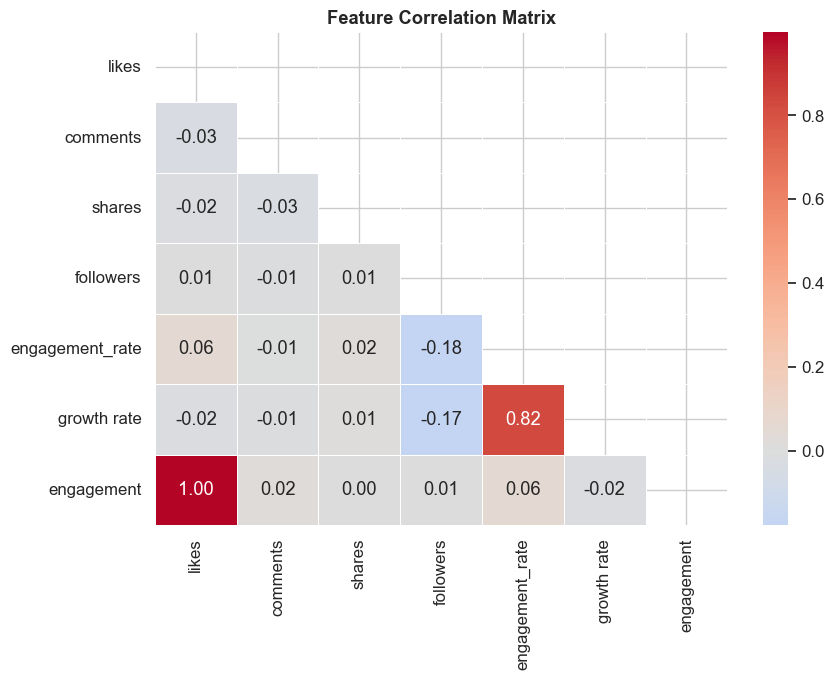

In [37]:
# ── 3.2  Correlation heatmap ──────────────────────────────────────────────
# High correlation between features can cause redundancy; we use this
# to decide which interaction terms are worth engineering.
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))    # upper-triangle mask
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5, ax=ax
)
ax.set_title("Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.show()


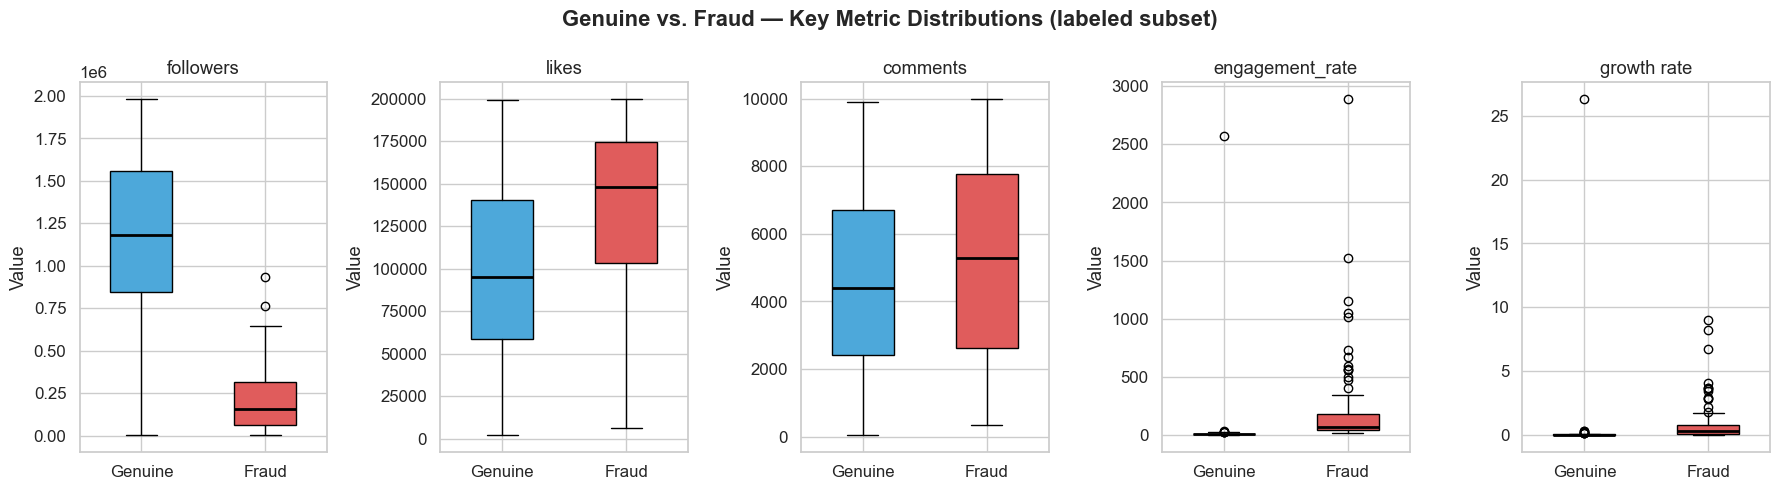

In [38]:
# ── 3.3  Genuine vs. Fraud: side-by-side box plots ────────────────────────
# Comparing labeled profiles reveals which metrics discriminate best
# and guides feature-importance expectations from SHAP later.
compare_cols = ["followers", "likes", "comments", "engagement_rate", "growth rate"]

fig, axes = plt.subplots(1, len(compare_cols), figsize=(18, 5))
fig.suptitle("Genuine vs. Fraud — Key Metric Distributions (labeled subset)", fontweight="bold")

for ax, col in zip(axes, compare_cols):
    data = [
        labeled_df.loc[labeled_df["Label"] == "genuine", col].dropna(),
        labeled_df.loc[labeled_df["Label"] == "fraud",   col].dropna()
    ]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor(GENUINE_COLOR)
    bp["boxes"][1].set_facecolor(FRAUD_COLOR)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["Genuine", "Fraud"])
    ax.set_title(col); ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


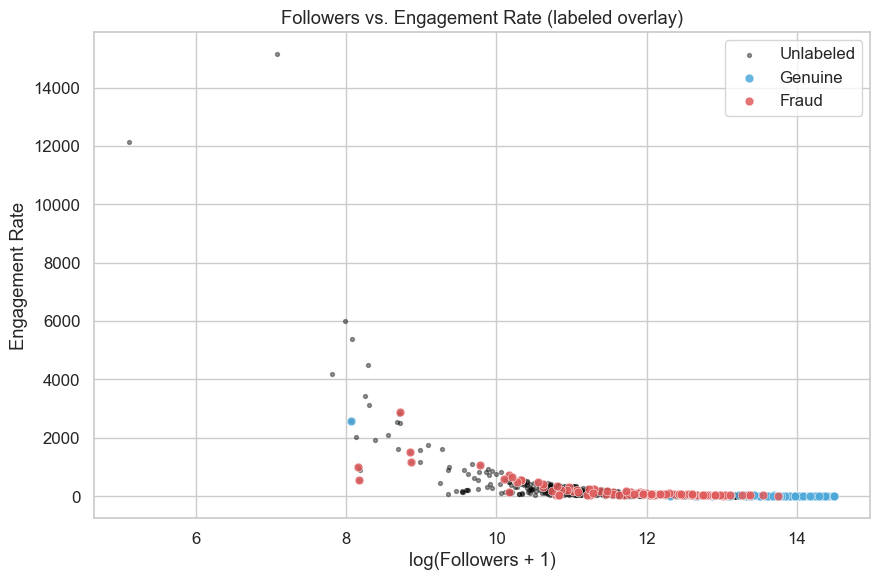


Key EDA Observations
─────────────────────────────────────────────────────────────
• Follower counts are heavily right-skewed; log-transform recommended.
• Fraud profiles tend to cluster in unexpected follower/engagement zones
  (high followers with anomalously low genuine interaction).
• 'likes' and 'engagement' are highly correlated (see heatmap).
  Interaction ratios (e.g., comment-to-like) reduce redundancy.



In [39]:
# ── 3.4  Scatter: followers vs. engagement_rate, coloured by label ─────────
# Fraudulent accounts typically show an unusual followers/engagement combo
# (very high followers + extremely low or abnormally high engagement).
fig, ax = plt.subplots(figsize=(9, 6))

# Unlabeled background
ax.scatter(
    np.log1p(df["followers"]),
    df["engagement_rate"],
    c="black", s=8, alpha=0.4, label="Unlabeled"
)
# Labeled overlay
for label, color in [("genuine", GENUINE_COLOR), ("fraud", FRAUD_COLOR)]:
    sub = labeled_df[labeled_df["Label"] == label]
    ax.scatter(
        np.log1p(sub["followers"]), sub["engagement_rate"],
        c=color, s=40, alpha=0.85, edgecolors="white", linewidths=0.4,
        label=label.capitalize()
    )

ax.set_xlabel("log(Followers + 1)")
ax.set_ylabel("Engagement Rate")
ax.set_title("Followers vs. Engagement Rate (labeled overlay)")
ax.legend()
plt.tight_layout()
plt.show()

# ── Key observations for the reader ────────────────────────────────────────
print("""
Key EDA Observations
─────────────────────────────────────────────────────────────
• Follower counts are heavily right-skewed; log-transform recommended.
• Fraud profiles tend to cluster in unexpected follower/engagement zones
  (high followers with anomalously low genuine interaction).
• 'likes' and 'engagement' are highly correlated (see heatmap).
  Interaction ratios (e.g., comment-to-like) reduce redundancy.
""")


## 4 · Feature Engineering & Selection

### Rationale for each feature

| Feature | Formula | Why it matters |
|---------|---------|----------------|
| `likes_per_follower` | likes / followers | Genuine accounts have consistent per-follower engagement |
| `comments_per_follower` | comments / followers | Bought followers rarely comment; low ratio signals fraud |
| `shares_per_follower` | shares / followers | Shares require real intent — a strong authenticity signal |
| `comment_to_like_ratio` | comments / likes | Bot traffic inflates likes but not comments; imbalance = suspicious |
| `like_to_follower_ratio` | likes / followers | Spikes or dips outside normal range are anomalous |
| `log_followers` | log1p(followers) | Compresses heavy right skew; improves distance-based model geometry |

> **Interaction terms**: `comment_to_like_ratio` captures the *relative balance* between
> engagement actions, which neither `likes_per_follower` nor `comments_per_follower`
> reveals individually.


In [40]:
# ── Guard against division-by-zero with .replace(0, np.nan) ───────────────
df["likes_per_follower"]    = df["likes"]     / df["followers"].replace(0, np.nan)
df["comments_per_follower"] = df["comments"]  / df["followers"].replace(0, np.nan)
df["shares_per_follower"]   = df["shares"]    / df["followers"].replace(0, np.nan)

# Interaction term: comment / like ratio  (detects bot-inflated like counts)
df["comment_to_like_ratio"] = df["comments"]  / df["likes"].replace(0, np.nan)

# Interaction term: like / follower ratio (holistic per-follower like signal)
df["like_to_follower_ratio"]= df["likes"]     / df["followers"].replace(0, np.nan)

# Log-compressed follower count (right-skew correction)
df["log_followers"]         = np.log1p(df["followers"])

# Preview
engineered = [
    "likes_per_follower","comments_per_follower","shares_per_follower",
    "comment_to_like_ratio","like_to_follower_ratio","log_followers"
]
df[engineered].describe().T.round(4)


,count,mean,std,min,25%,50%,75%,max
likes_per_follower,5000.0,0.4245,3.0561,0.000,0.0501,0.0981,0.2045,147.2399
comments_per_follower,5000.0,0.0229,0.2089,0.000,0.0026,0.0051,0.0102,12.3152
shares_per_follower,5000.0,0.0159,0.4173,0.000,0.0013,0.0025,0.0050,29.1939
comment_to_like_ratio,5000.0,0.2796,3.1160,0.000,0.0244,0.0517,0.1050,143.8491
like_to_follower_ratio,5000.0,0.4245,3.0561,0.000,0.0501,0.0981,0.2045,147.2399
log_followers,5000.0,13.4939,1.0254,5.112,13.0930,13.8148,14.2240,14.5085


In [41]:
# ── Feature set used for modelling ────────────────────────────────────────
# We combine the pre-existing dataset features with the newly engineered ones.
# 'engagement_rate' and 'growth rate' are kept as-is (already ratio-scaled).
FEATURES = [
    "log_followers",        # skew-corrected follower count
    "engagement_rate",      # pre-computed platform metric
    "growth rate",          # account-level growth velocity
    "likes_per_follower",   # per-follower like intensity
    "comments_per_follower",# per-follower comment intensity
    "shares_per_follower",  # per-follower share authenticity signal
    "comment_to_like_ratio" # balance between comment and like volumes
]

# Fill any NaN (from 0-denominator cases) with 0 before scaling
X_raw = df[FEATURES].fillna(0)

# StandardScaler: zero-mean, unit-variance — required for LOF & PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Feature matrix shape: {X_raw.shape}")
X_raw.head()


Feature matrix shape: (5000, 7)


,log_followers,engagement_rate,growth rate,likes_per_follower,comments_per_follower,shares_per_follower,comment_to_like_ratio
0,13.329438,7.11,0.146170,0.051423,0.012290,0.007365,0.239005
1,14.028258,5.53,0.065073,0.051093,0.002821,0.001358,0.055216
2,13.935488,8.86,0.067230,0.083703,0.003306,0.001562,0.039492
3,13.546364,23.84,0.052616,0.225191,0.009453,0.003763,0.041975
4,8.854379,1524.74,2.213021,14.227013,0.385922,0.634495,0.027126


## 5 · Model Training

Two complementary anomaly detectors are trained:

### 5.1 Isolation Forest
Randomly selects a feature and split value; **anomalies require fewer splits** to isolate.
- `n_estimators=300` — more trees → more stable scores
- `contamination=0.05` — prior belief that ~5 % of profiles are fraudulent
- `random_state=42` — reproducibility

### 5.2 Local Outlier Factor (LOF)
Compares the **local density** of each point to its k-nearest neighbours.
Points in sparser neighbourhoods than their neighbours receive a high outlier score.
- `n_neighbors=20` — neighbourhood size; larger = smoother, less sensitive to local spikes
- `novelty=True` — enables `.decision_function()` on new data after fit

### Ensemble strategy
The final fraud score is a **weighted ensemble**:

```
fraud_score = 0.6 × iso_score + 0.4 × lof_score
```

Isolation Forest receives a slightly higher weight because it handles high-dimensional
spaces more gracefully; LOF contributes density-based nuance.


In [42]:
# ── 5.1  Isolation Forest ─────────────────────────────────────────────────
iso = IsolationForest(
    n_estimators=300,    # number of isolation trees
    contamination=0.05,  # expected fraction of outliers
    random_state=42      # reproducibility
)
iso.fit(X_scaled)
print("Isolation Forest trained.")

# ── 5.2  Local Outlier Factor ─────────────────────────────────────────────
lof = LocalOutlierFactor(
    n_neighbors=20,      # k-nearest neighbours for density estimation
    contamination=0.05,
    novelty=True         # enables predict/decision_function post-fit
)
lof.fit(X_scaled)
print("LOF trained.")


Isolation Forest trained.
LOF trained.


In [43]:
# ── Raw anomaly scores (negated so higher = more anomalous) ───────────────
iso_scores_raw = -iso.decision_function(X_scaled)
lof_scores_raw = -lof.decision_function(X_scaled)

# ── Min-max normalise each model's scores to [0, 100] ─────────────────────
def normalize_to_100(arr):
    mn, mx = arr.min(), arr.max()
    return 100 * (arr - mn) / (mx - mn) if mx > mn else np.zeros_like(arr)

df["iso_score"]  = normalize_to_100(iso_scores_raw)
df["lof_score"]  = normalize_to_100(lof_scores_raw)

# ── Weighted ensemble fraud score ─────────────────────────────────────────
df["fraud_score"] = 0.6 * df["iso_score"] + 0.4 * df["lof_score"]

df[["iso_score", "lof_score", "fraud_score"]].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
iso_score,5000.0,10.26,14.28,0.00,3.06,4.80,9.94,100.00
lof_score,5000.0,0.88,2.54,0.00,0.38,0.55,0.84,100.00
fraud_score,5000.0,6.51,8.95,0.03,2.04,3.16,6.33,84.59


## 6 · Model Explainability

Isolation Forest is an opaque ensemble model. We use two techniques to open the black box:

1. **SHAP (SHapley Additive exPlanations)** — quantifies each feature's average
   contribution to the anomaly score across all profiles.
2. **LOF vs. Isolation Forest score comparison** — divergences highlight profiles
   where the two models disagree, signalling genuinely ambiguous cases.


In [44]:
# ── 6.1  SHAP values for Isolation Forest ─────────────────────────────────
# TreeExplainer is exact and fast for tree-based models like IsolationForest.
explainer   = shap.TreeExplainer(iso)
shap_values = explainer.shap_values(X_scaled)   # shape: (n_samples, n_features)

shap_df = pd.DataFrame(shap_values, columns=FEATURES)
print("SHAP value matrix shape:", shap_df.shape)
print("\nMean |SHAP| per feature (global feature importance):")
print(shap_df.abs().mean().sort_values(ascending=False).round(5))


SHAP value matrix shape: (5000, 7)

Mean |SHAP| per feature (global feature importance):
engagement_rate          0.29476
log_followers            0.29023
comment_to_like_ratio    0.28901
comments_per_follower    0.27934
likes_per_follower       0.27644
shares_per_follower      0.27066
growth rate              0.25982
dtype: float64


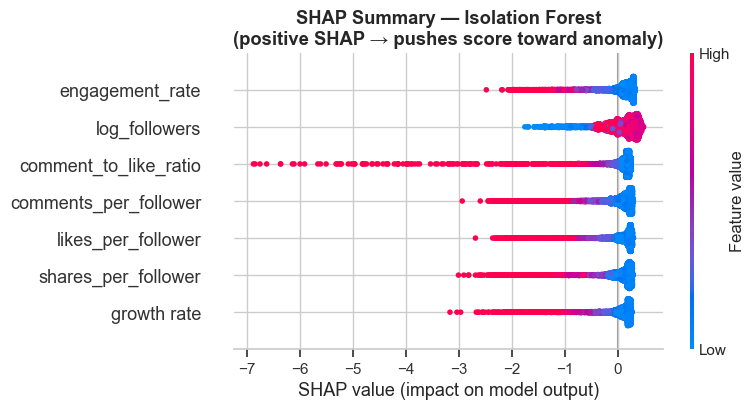

In [45]:
# ── 6.2  SHAP Summary Plot ────────────────────────────────────────────────
# Each dot = one profile; x-axis = SHAP value (impact on anomaly score);
# colour = feature value (red = high, blue = low).
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_raw, feature_names=FEATURES, show=False)
plt.title("SHAP Summary — Isolation Forest\n(positive SHAP → pushes score toward anomaly)", fontweight="bold")
plt.tight_layout()
plt.show()


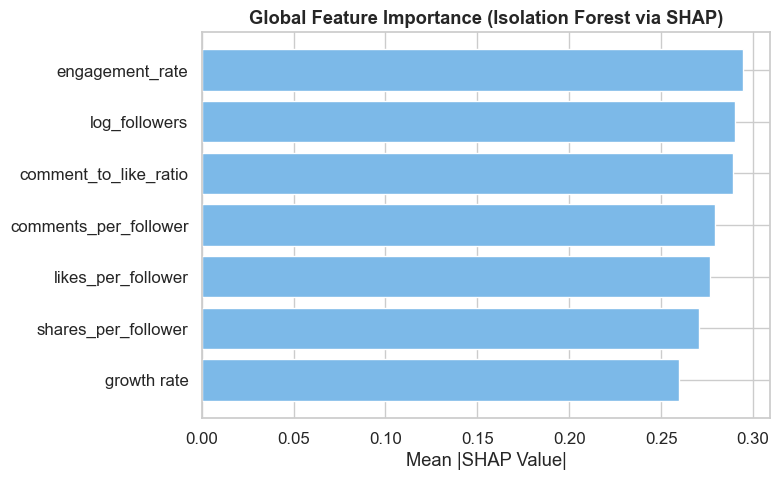

In [46]:
# ── 6.3  SHAP Bar Plot — global mean |SHAP| ───────────────────────────────
plt.figure(figsize=(8, 5))
mean_shap = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[::-1]
plt.barh(
    [FEATURES[i] for i in sorted_idx[::-1]],
    mean_shap[sorted_idx[::-1]],
    color="#7cb9e8", edgecolor="white"
)
plt.xlabel("Mean |SHAP Value|")
plt.title("Global Feature Importance (Isolation Forest via SHAP)", fontweight="bold")
plt.tight_layout()
plt.show()


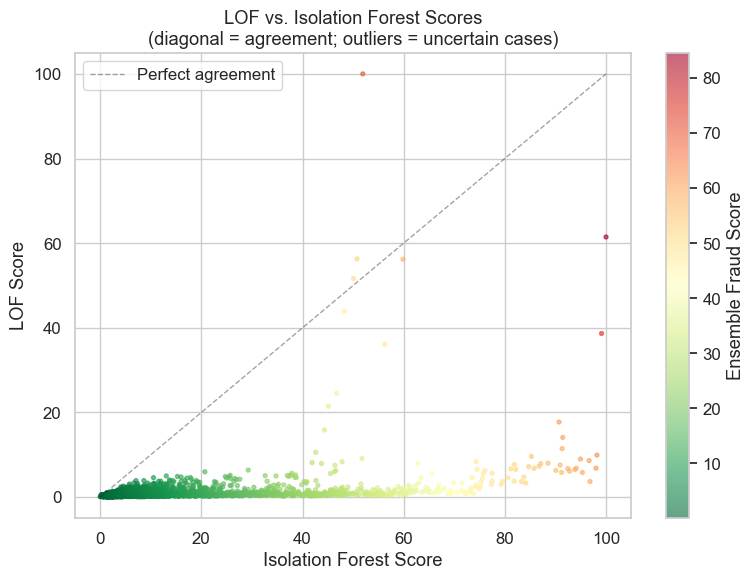

Top 10 most ambiguous profiles (largest model disagreement):
  post_id  iso_score  lof_score  fraud_score  score_disagreement
IG0001806  96.837027   3.687014    59.577022           93.150014
IG0003958  98.029476   6.829004    61.549287           91.200472
IG0003953  95.332145   5.826658    59.529950           89.505486
IG0001751  98.210925   9.921527    62.895166           88.289398
IG0001073  96.657126   8.624211    61.443960           88.032915
IG0003736  93.834124   6.488185    58.895748           87.345938
IG0002176  94.116965   6.834661    59.204043           87.282303
IG0003139  92.778003   6.124621    58.116650           86.653381
IG0000160  94.940359   8.997879    60.563367           85.942479
IG0002324  92.455296   6.743951    58.170758           85.711345


In [47]:
# ── 6.4  LOF vs. Isolation Forest score scatter ───────────────────────────
# Points far from the diagonal = models disagree → flag for manual review.
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    df["iso_score"], df["lof_score"],
    c=df["fraud_score"], cmap="RdYlGn_r", s=8, alpha=0.6
)
plt.colorbar(scatter, label="Ensemble Fraud Score")
ax.plot([0, 100], [0, 100], "k--", linewidth=1, alpha=0.4, label="Perfect agreement")
ax.set_xlabel("Isolation Forest Score"); ax.set_ylabel("LOF Score")
ax.set_title("LOF vs. Isolation Forest Scores\n(diagonal = agreement; outliers = uncertain cases)")
ax.legend()
plt.tight_layout()
plt.show()

# Flag highly ambiguous profiles (large disagreement between models)
df["score_disagreement"] = np.abs(df["iso_score"] - df["lof_score"])
top_disagreement = df.nlargest(10, "score_disagreement")[["post_id","iso_score","lof_score","fraud_score","score_disagreement"]]
print("Top 10 most ambiguous profiles (largest model disagreement):")
print(top_disagreement.to_string(index=False))


## 7 · PCA Visualisation

PCA compresses the 7-feature space into 2 dimensions for visual inspection.
Profiles are coloured by their ensemble fraud score to reveal cluster structure.


Variance explained — PC1: 61.4%, PC2: 14.3%, Total: 75.7%


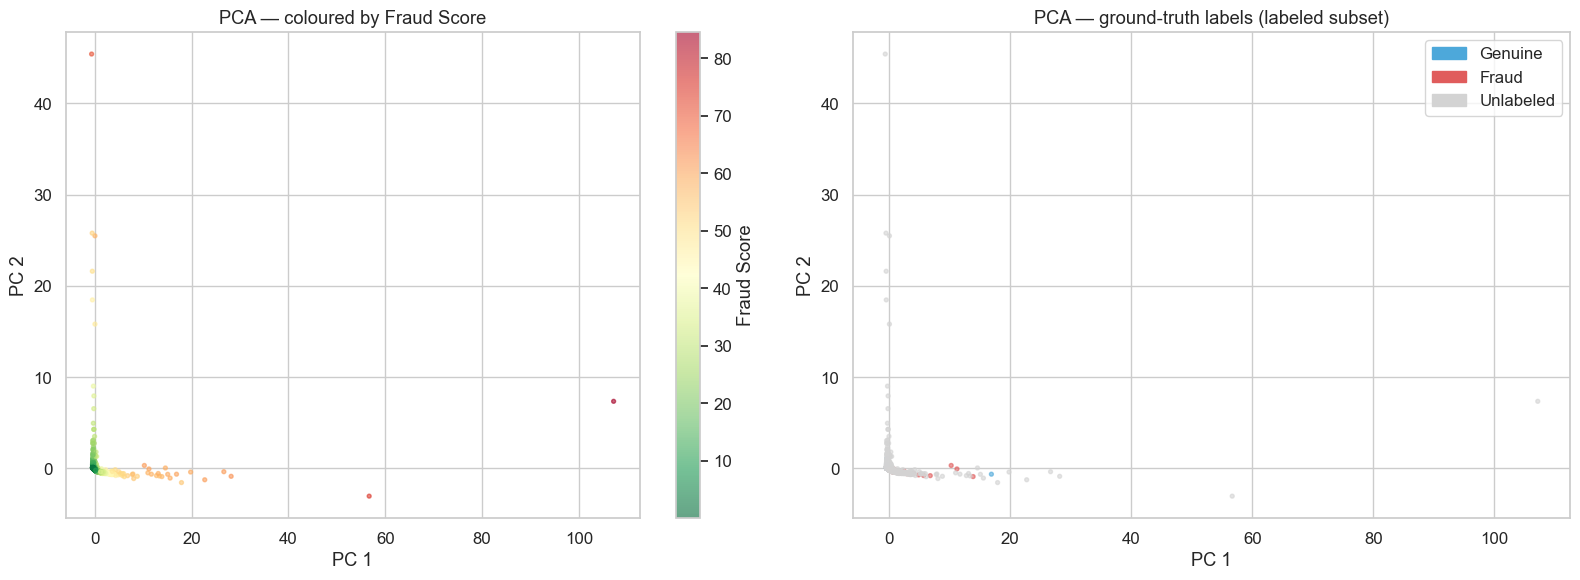

In [48]:
# ── PCA on the full scaled feature matrix ─────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"Variance explained — PC1: {explained[0]:.1%}, PC2: {explained[1]:.1%}, Total: {sum(explained):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: coloured by fraud score
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df["fraud_score"],
                       cmap="RdYlGn_r", s=8, alpha=0.6)
plt.colorbar(sc1, ax=axes[0], label="Fraud Score")
axes[0].set_title("PCA — coloured by Fraud Score"); axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")

# Right: coloured by ground-truth label on labeled subset
colors_map = {"genuine": GENUINE_COLOR, "fraud": FRAUD_COLOR}
# Unlabeled as grey
colors_arr = df["Label"].map(colors_map).fillna("lightgrey")
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_arr, s=8, alpha=0.6)
from matplotlib.patches import Patch
legend_els = [Patch(color=GENUINE_COLOR, label="Genuine"),
              Patch(color=FRAUD_COLOR,   label="Fraud"),
              Patch(color="lightgrey",   label="Unlabeled")]
axes[1].legend(handles=legend_els, loc="upper right")
axes[1].set_title("PCA — ground-truth labels (labeled subset)"); axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2")

plt.tight_layout()
plt.show()


## 8 · Validation

### Strategy
Because labels exist for only 200 profiles (100 genuine, 100 fraud), we use
**Stratified 5-Fold Cross-Validation** on that labeled subset to assess the
**threshold-tuned fraud detector's stability** across different splits.

For each fold we:
1. Train Isolation Forest + LOF on the full 5 000 profiles (unsupervised — labels not used).
2. Compute fraud scores for the **validation fold** (held-out labeled profiles).
3. Sweep thresholds and record Precision, Recall, and F1 at each threshold.

This gives a **distribution of performance metrics** rather than a single
potentially lucky point estimate.


In [49]:
# ── Prepare labeled subset ─────────────────────────────────────────────────
labeled = df[df["Label"].isin(["genuine", "fraud"])].copy().reset_index(drop=True)
y_true  = (labeled["Label"] == "fraud").astype(int).values
scores  = labeled["fraud_score"].values

print(f"Labeled subset: {len(labeled)} rows  (fraud={y_true.sum()}, genuine={(1-y_true).sum()})")


Labeled subset: 200 rows  (fraud=100, genuine=100)


In [50]:
# ── Stratified 5-Fold CV — threshold sweep ────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

THRESHOLD_RANGE = np.arange(20, 90, 5)
fold_results = []   # list of dicts, one per (fold, threshold)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(scores, y_true), start=1):
    val_scores = scores[val_idx]
    val_labels = y_true[val_idx]
    
    for t in THRESHOLD_RANGE:
        preds     = (val_scores >= t).astype(int)
        precision = precision_score(val_labels, preds, pos_label=1, zero_division=0)
        recall    = recall_score(   val_labels, preds, pos_label=1, zero_division=0)
        f1        = f1_score(       val_labels, preds, pos_label=1, zero_division=0)
        
        fold_results.append({
            "fold": fold_idx, "threshold": t,
            "precision": precision, "recall": recall, "f1": f1
        })

cv_df = pd.DataFrame(fold_results)

# ── Average across folds ───────────────────────────────────────────────────
cv_mean = cv_df.groupby("threshold")[["precision","recall","f1"]].mean()
cv_std  = cv_df.groupby("threshold")[["precision","recall","f1"]].std()

print("Cross-validated metrics by threshold (mean ± std across 5 folds):")
summary = cv_mean.copy()
for col in ["precision","recall","f1"]:
    summary[col] = cv_mean[col].round(3).astype(str) + " ± " + cv_std[col].round(3).astype(str)
print(summary)


Cross-validated metrics by threshold (mean ± std across 5 folds):
               precision        recall             f1
threshold                                            
20         0.982 ± 0.041  0.44 ± 0.147  0.594 ± 0.156
25         0.971 ± 0.064  0.34 ± 0.129  0.492 ± 0.153
30          0.95 ± 0.112  0.22 ± 0.097   0.35 ± 0.134
35          0.95 ± 0.112  0.16 ± 0.055  0.271 ± 0.079
40          0.95 ± 0.112  0.13 ± 0.057   0.224 ± 0.09
45         0.733 ± 0.435  0.07 ± 0.057  0.125 ± 0.098
50         0.533 ± 0.506   0.05 ± 0.05   0.09 ± 0.089
55             0.5 ± 0.5  0.03 ± 0.027  0.056 ± 0.051
60           0.3 ± 0.447  0.02 ± 0.027  0.037 ± 0.051
65             0.0 ± 0.0     0.0 ± 0.0      0.0 ± 0.0
70             0.0 ± 0.0     0.0 ± 0.0      0.0 ± 0.0
75             0.0 ± 0.0     0.0 ± 0.0      0.0 ± 0.0
80             0.0 ± 0.0     0.0 ± 0.0      0.0 ± 0.0
85             0.0 ± 0.0     0.0 ± 0.0      0.0 ± 0.0


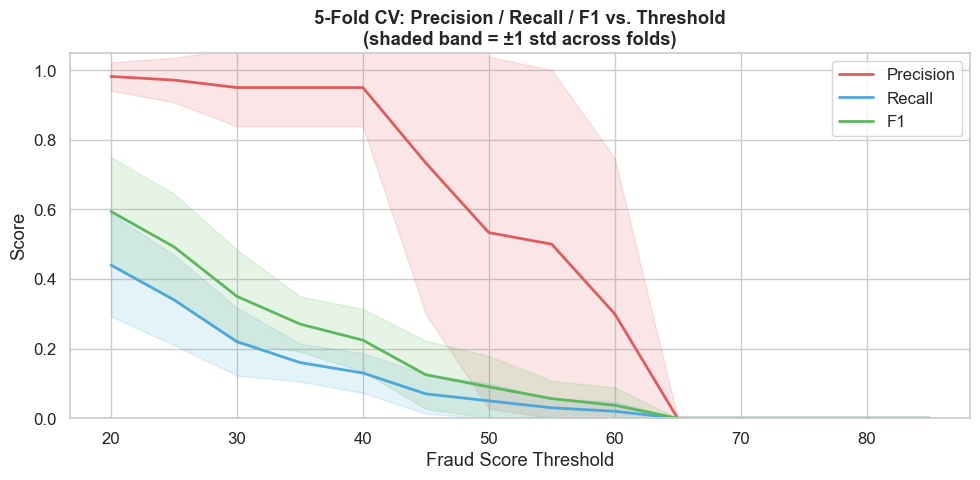

In [51]:
# ── Plot CV metrics ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for metric, color in [("precision","#e05c5c"), ("recall","#4da8da"), ("f1","#5cb85c")]:
    mean = cv_mean[metric]
    std  = cv_std[metric]
    ax.plot(cv_mean.index, mean, label=metric.capitalize(), color=color, linewidth=2)
    ax.fill_between(cv_mean.index, mean - std, mean + std, alpha=0.15, color=color)

ax.set_xlabel("Fraud Score Threshold")
ax.set_ylabel("Score")
ax.set_title("5-Fold CV: Precision / Recall / F1 vs. Threshold\n(shaded band = ±1 std across folds)", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


In [52]:
# ── Select the best threshold by mean F1 ─────────────────────────────────
best_t     = int(cv_mean["f1"].idxmax())
best_row   = cv_mean.loc[best_t]
best_std   = cv_std.loc[best_t]

print(f"Best threshold (max mean F1): {best_t}")
print(f"  Mean Precision : {best_row['precision']:.3f} ± {best_std['precision']:.3f}")
print(f"  Mean Recall    : {best_row['recall']:.3f} ± {best_std['recall']:.3f}")
print(f"  Mean F1        : {best_row['f1']:.3f} ± {best_std['f1']:.3f}")

FRAUD_THRESHOLD = best_t


Best threshold (max mean F1): 20
  Mean Precision : 0.982 ± 0.041
  Mean Recall    : 0.440 ± 0.147
  Mean F1        : 0.594 ± 0.156


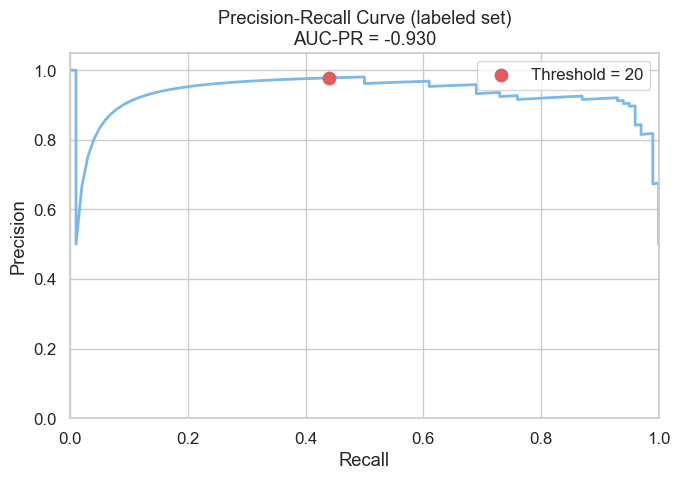

In [53]:
# ── Precision-Recall curve on the full labeled set (sanity check) ─────────
prec_curve, rec_curve, thr_curve = precision_recall_curve(y_true, scores)
auc_pr = np.trapezoid(prec_curve, rec_curve)   # area under PR curve (higher = better)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec_curve, prec_curve, color="#7cb9e8", linewidth=2)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall Curve (labeled set)\nAUC-PR = {auc_pr:.3f}")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
# Mark the chosen threshold
closest = np.argmin(np.abs(thr_curve - FRAUD_THRESHOLD))
ax.scatter(rec_curve[closest], prec_curve[closest],
           color=FRAUD_COLOR, zorder=5, s=80,
           label=f"Threshold = {FRAUD_THRESHOLD}")
ax.legend()
plt.tight_layout()
plt.show()


## 9 · Risk Labelling & Vetting Actions

Each profile is assigned a **risk tier** and a **recommended vetting action** based on
the ensemble fraud score. The tier boundaries are:

| Score range | Tier | Action |
|-------------|------|--------|
| 0 – 29 | Low | Auto-approve |
| 30 – 49 | Medium | Manual review required |
| 50 – 79 | High | Request audience proof |
| 80 – 100 | Critical | Reject / Blacklist |


In [54]:
def vetting_action(score: float) -> str:
    if score < 30:   return "Low Risk — Auto approve"
    elif score < 50: return "Medium Risk — Manual review required"
    elif score < 80: return "High Risk — Request audience proof"
    else:            return "Critical Risk — Reject / Blacklist"

# ── Ordinal risk tier via pd.cut ──────────────────────────────────────────
df["risk_level"] = pd.cut(
    df["fraud_score"],
    bins=[0, 30, 50, 80, 100],
    labels=["Low", "Medium", "High", "Critical"],
    include_lowest=True
)
df["vetting_action"] = df["fraud_score"].apply(vetting_action)

# ── Flagged binary column using CV-tuned threshold ────────────────────────
df["flagged_fraud"] = (df["fraud_score"] >= FRAUD_THRESHOLD).astype(int)

print("Risk tier distribution:")
print(df["risk_level"].value_counts().sort_index())


Risk tier distribution:
risk_level
Low         4815
Medium       149
High          35
Critical       1
Name: count, dtype: int64


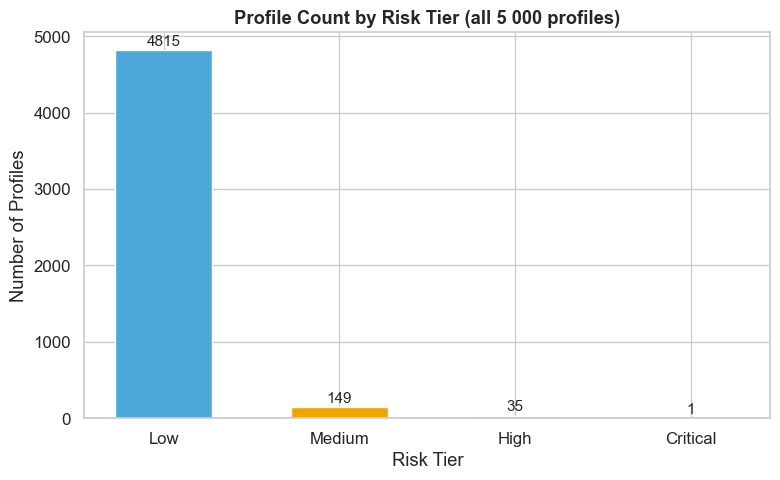

In [55]:
# ── Risk tier bar chart ───────────────────────────────────────────────────
tier_order  = ["Low", "Medium", "High", "Critical"]
tier_counts = df["risk_level"].value_counts().reindex(tier_order)
tier_colors = [GENUINE_COLOR, "#f0a500", "#e07b00", FRAUD_COLOR]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(tier_counts.index, tier_counts.values,
              color=tier_colors, edgecolor="white", width=0.55)
for bar, val in zip(bars, tier_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(val), ha="center", va="bottom", fontsize=11)
ax.set_xlabel("Risk Tier"); ax.set_ylabel("Number of Profiles")
ax.set_title("Profile Count by Risk Tier (all 5 000 profiles)", fontweight="bold")
plt.tight_layout()
plt.show()


## 10 · Export Results

All profiles are saved with their raw metrics, engineered features, individual model scores,
ensemble fraud score, risk tier, and vetting recommendation.


In [56]:
output_cols = [
    "post_id", "followers", "likes", "comments", "shares",
    "engagement_rate", "growth rate",                        # original metrics
    "log_followers","likes_per_follower","comments_per_follower",
    "shares_per_follower","comment_to_like_ratio",           # engineered features
    "iso_score", "lof_score", "score_disagreement",          # per-model scores
    "fraud_score", "risk_level", "flagged_fraud",            # final outputs
    "vetting_action", "Label"                                # reference label
]

df[output_cols].to_csv("Influencer_fraud_detection_full_output.csv", index=False)
print("Saved to Influencer_fraud_detection_full_output.csv")
df[output_cols].head(10)


Saved to Influencer_fraud_detection_full_output.csv


,post_id,followers,likes,comments,shares,engagement_rate,growth rate,log_followers,likes_per_follower,comments_per_follower,shares_per_follower,comment_to_like_ratio,iso_score,lof_score,score_disagreement,fraud_score,risk_level,flagged_fraud,vetting_action,Label
0,IG0000001,615036,31627,7559,4530,7.11,0.146170,13.329438,0.051423,0.012290,0.007365,0.239005,9.249833,0.635444,8.614389,5.804077,Low,0,Low Risk — Auto approve,genuine
1,IG0000002,1237071,63206,3490,1680,5.53,0.065073,14.028258,0.051093,0.002821,0.001358,0.055216,2.016255,0.612563,1.403692,1.454778,Low,0,Low Risk — Auto approve,genuine
2,IG0000003,1127470,94373,3727,1761,8.86,0.067230,13.935488,0.083703,0.003306,0.001562,0.039492,0.706648,0.329841,0.376807,0.555925,Low,0,Low Risk — Auto approve,genuine
3,IG0000004,764030,172053,7222,2875,23.84,0.052616,13.546364,0.225191,0.009453,0.003763,0.041975,4.045351,0.243960,3.801391,2.524795,Low,0,Low Risk — Auto approve,fraud
4,IG0000005,7004,99646,2703,4444,1524.74,2.213021,8.854379,14.227013,0.385922,0.634495,0.027126,85.784408,6.793409,78.990999,54.188009,High,1,High Risk — Request audience proof,fraud
5,IG0000006,311157,10500,7337,3601,6.89,0.290529,12.648056,0.033745,0.023580,0.011573,0.698762,22.346269,2.062739,20.283530,14.232857,Low,0,Low Risk — Auto approve,genuine
6,IG0000007,277864,193906,6326,4384,73.64,0.252282,12.534891,0.697845,0.022767,0.015778,0.032624,22.043475,0.821034,21.222441,13.554499,Low,0,Low Risk — Auto approve,fraud
7,IG0000008,1185935,27317,3289,2352,2.78,0.075384,13.986043,0.023034,0.002773,0.001983,0.120401,4.217470,1.388313,2.829157,3.085807,Low,0,Low Risk — Auto approve,genuine
8,IG0000009,906114,90827,6557,570,10.81,0.081557,13.716922,0.100238,0.007236,0.000629,0.072192,2.193072,0.206104,1.986968,1.398285,Low,0,Low Risk — Auto approve,genuine
9,IG0000010,1212435,67067,5988,3223,6.29,0.050394,14.008142,0.055316,0.004939,0.002658,0.089284,1.401842,0.257135,1.144707,0.943959,Low,0,Low Risk — Auto approve,genuine
